In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-10 15:43:28.478336


# Preliminary QC -- Filter transcript count, floor threshold

Workflow: filter only cells with very few counts. Then proceed to remove peyer's patches, run scrublet, filter on area.

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import sys
import session_info

### Set paths, import data

In [3]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = base_dir / "data/h5ad/export_01/01_raw/output_folder"
output_dir = base_dir / "data/h5ad/export_01/02_pre-filtered"

os.makedirs(output_dir, exist_ok=True)

Make a list of files in the directory:

In [4]:
sample_list = os.listdir(input_dir)
sample_list

['TMA00304.h5ad', 'TMA00306.h5ad', 'TMA00303.h5ad', 'TMA00305.h5ad']

Add samples to list if they end in .h5ad:

In [5]:
sample_files = [
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.endswith(".h5ad") and f.startswith("TMA")
]

adata_list = [ad.read_h5ad(f) for f in sample_files]

for f, adata in zip(sample_files, adata_list):
    print(f"{os.path.basename(f)} > {adata.n_obs:,} cells × {adata.n_vars:,} genes")

TMA00304.h5ad > 24,375 cells × 480 genes
TMA00306.h5ad > 37,315 cells × 480 genes
TMA00303.h5ad > 12,755 cells × 480 genes
TMA00305.h5ad > 38,753 cells × 480 genes


## Filter

Filtering based on total cell count thresholds from Max's paper.

In [6]:
def plot_violin_subplots(adata_list, obs_keys):
    n = len(adata_list)
    fig, axs = plt.subplots(1, n, figsize=(6 * n, 5))
    
    if n == 1:
        axs = [axs]  # make iterable if only one sample

    for ax, adata in zip(axs, adata_list):
        sc.pl.violin(adata, obs_keys, show=False, ax=ax)
        ax.set_title(getattr(adata, 'filename', 'Sample'))

    plt.tight_layout()
    plt.show()

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

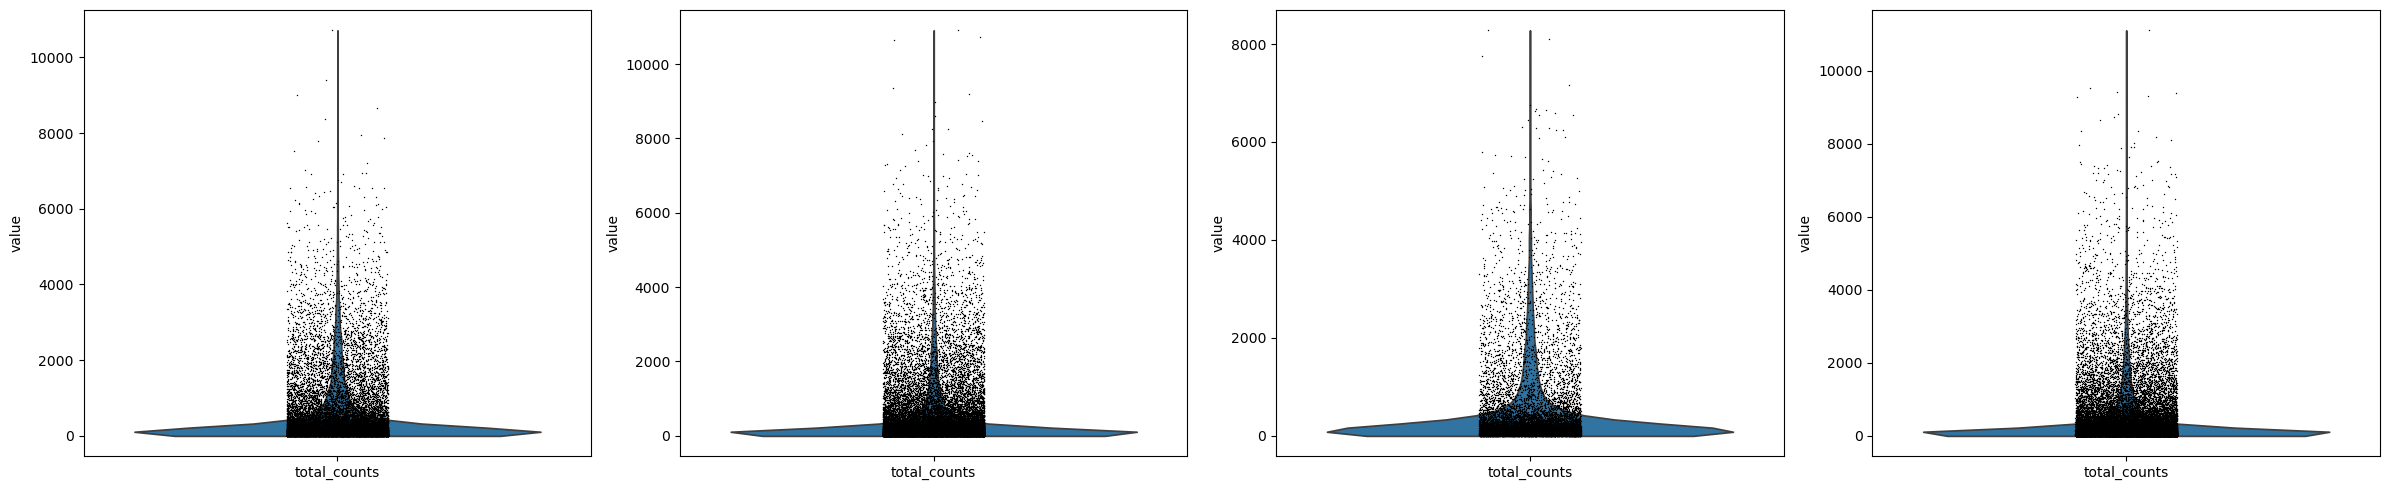

In [7]:
plot_violin_subplots(adata_list, ['total_counts'])

In [8]:
# Total counts
## Floor threshold
for i, adata in enumerate(adata_list):
    print(f"Dataset {i} shape before total_counts floor threshold: {adata.shape}")
    adata_list[i] = adata[adata.obs['total_counts'] > 20, :].copy()
    print(f"Dataset {i} shape after total_counts floor threshold: {adata_list[i].shape}")

Dataset 0 shape before total_counts floor threshold: (24375, 480)
Dataset 0 shape after total_counts floor threshold: (21501, 480)
Dataset 1 shape before total_counts floor threshold: (37315, 480)
Dataset 1 shape after total_counts floor threshold: (32284, 480)
Dataset 2 shape before total_counts floor threshold: (12755, 480)
Dataset 2 shape after total_counts floor threshold: (11408, 480)
Dataset 3 shape before total_counts floor threshold: (38753, 480)
Dataset 3 shape after total_counts floor threshold: (33118, 480)


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

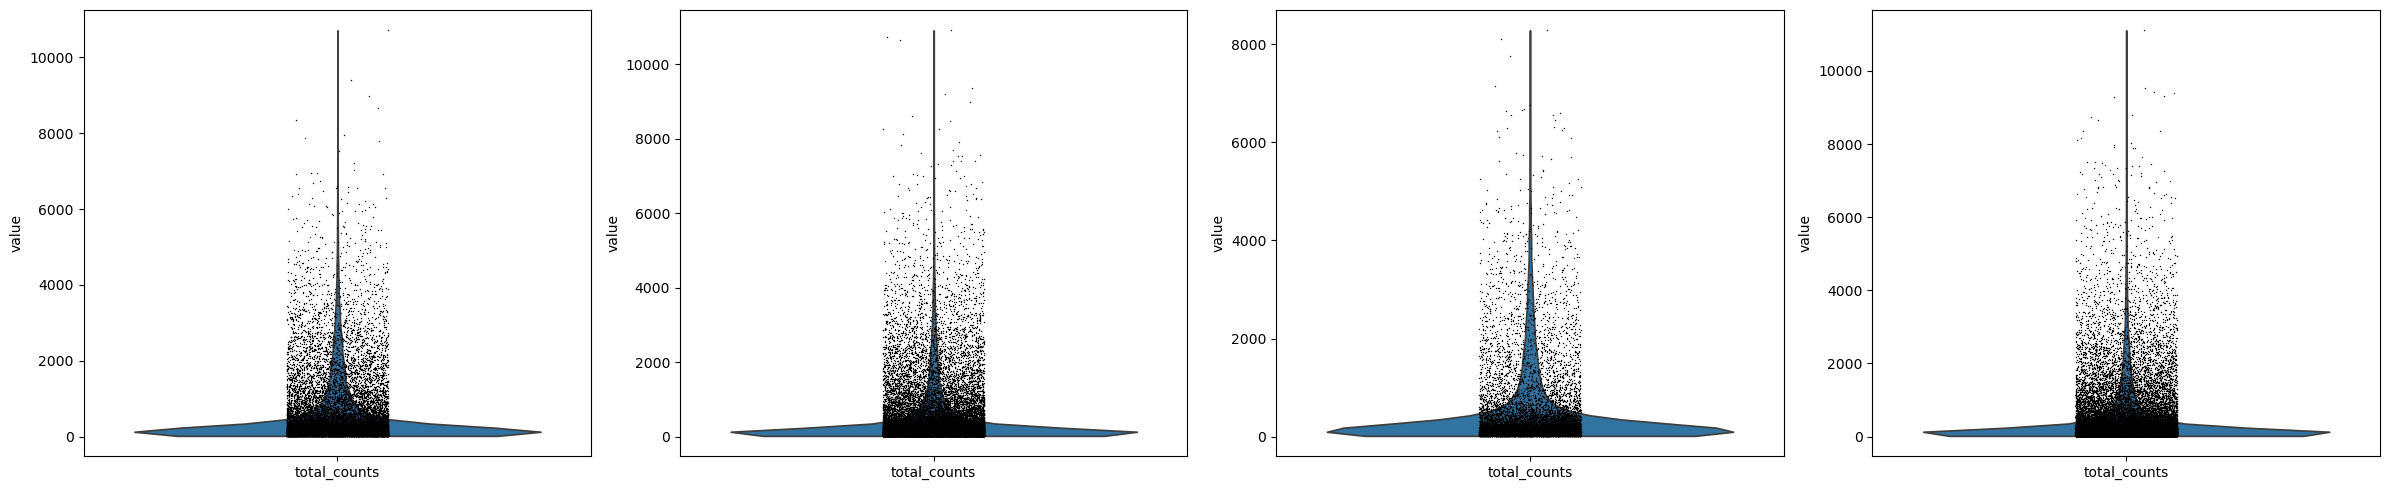

In [9]:
plot_violin_subplots(adata_list, ['total_counts'])

## Export

In [10]:
# From previous QC (without scrublet)
#filename = os.path.join(output_dir, 'artis-naive-pp.h5ad')
#os.makedirs(os.path.dirname(filename), exist_ok=True)

#adata.write_h5ad(filename, compression='gzip')
#print(f'Filtered, concatenated adata saved to: {filename}')

In [13]:
for i, adata in enumerate(adata_list):
    sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
    output_file = os.path.join(output_dir, f"{sample_name}.h5ad")
    
    adata.write(output_file)
    print(f"Saved: {output_file}")

/tmp/ipykernel_3330/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_3330/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_3330/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

Saved: /home/workspace/projects/drg/data/h5ad/export_01/02_pre-filtered/TMA00304.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/02_pre-filtered/TMA00306.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/02_pre-filtered/TMA00303.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/02_pre-filtered/TMA00305.h5ad


/tmp/ipykernel_3330/10927029.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"


## Session info

In [12]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-spatial
